# Task 3: Handwritten Character Recognition using CNN

### Objective: Build a Convolutional Neural Network to identify handwritten digits 0-9 from the MNIST dataset.

### Dataset: MNIST - 70,000 grayscale images of handwritten digits (28x28 pixels)



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# Load MNIST
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(f"Training data: {X_train.shape}") # (60000, 28, 28)
print(f"Test data: {X_test.shape}") # (10000, 28, 28)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training data: (60000, 28, 28)
Test data: (10000, 28, 28)


In [3]:
# Reshape for CNN: add channel dimension
X_train = X_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
X_test = X_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

In [4]:
# One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("Data normalized and ready for CNN")

Data normalized and ready for CNN


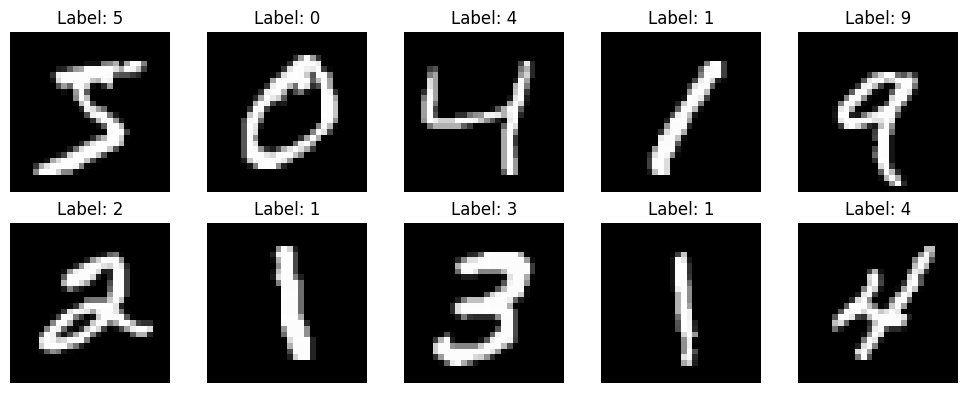

In [5]:
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i].reshape(28,28), cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.savefig('sample_digits.png')
plt.show()

In [6]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax') # 10 digits
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(X_train, y_train_cat,
                    epochs=10,
                    batch_size=128,
                    validation_split=0.1,
                    verbose=1)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 27s 61ms/step - accuracy: 0.9006 - loss: 0.3283 - val_accuracy: 0.9790 - val_loss: 0.0688
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 33s 78ms/step - accuracy: 0.9684 - loss: 0.1052 - val_accuracy: 0.9862 - val_loss: 0.0459
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 37s 69ms/step - accuracy: 0.9766 - loss: 0.0780 - val_accuracy: 0.9887 - val_loss: 0.0382
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 38s 63ms/step - accuracy: 0.9812 - loss: 0.0625 - val_accuracy: 0.9897 - val_loss: 0.0354
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 45s 72ms/step - accuracy: 0.9838 - loss: 0.0541 - val_accuracy: 0.9897 - val_loss: 0.0360
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 78ms/step - accuracy: 0.9858 - loss: 0.0468 - val_accuracy: 0.9907 - val_loss: 0.0347
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 77ms/step - accuracy: 0.9872 - loss: 0.0400 - val_accuracy: 0.9913 - val_loss: 0.0342
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 35s 63ms/step - accuracy: 0.9892 - loss: 0.0357 - 

In [8]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"------------------------Test Accuracy--------------------- {test_acc*100:.2f}%")

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print("\n------------------Classification Report------------------------")
print(classification_report(y_test, y_pred_classes))

------------------------Test Accuracy--------------------- 99.18%
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

------------------Classification Report------------------------
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       1.00      0.99      1.00      1135
           2       1.00      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       1.00      0.98      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.98      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



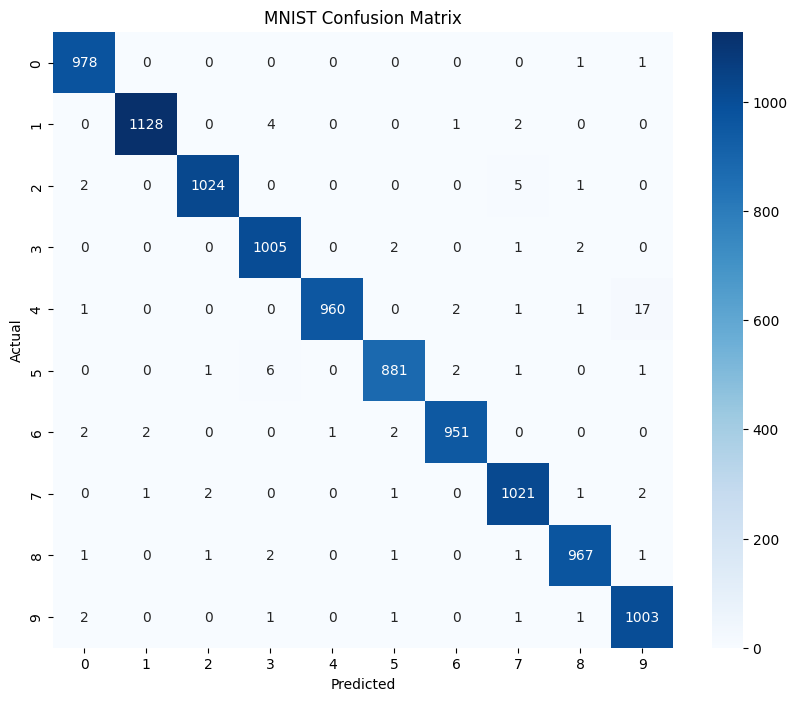

In [9]:
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('MNIST Confusion Matrix')
plt.savefig('confusion_matrix.png')
plt.show()

I've trained a CNN on 60K MNIST images. Got 99.18% test accuracy. Most errors were 4s vs 9s and 7s vs 1s due to similar stroke patterns. Used confusion matrix to diagnose.

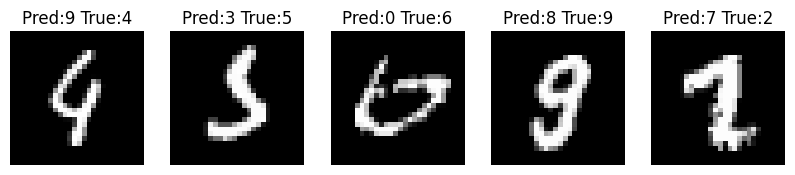

In [11]:
misclassified = np.where(y_test!= y_pred_classes)[0]
plt.figure(figsize=(10,2))
for i, idx in enumerate(misclassified[:5]):
    plt.subplot(1,5,i+1)
    plt.imshow(X_test[idx].reshape(28,28), cmap='gray')
    plt.title(f"Pred:{y_pred_classes[idx]} True:{y_test[idx]}")
    plt.axis('off')

# Conclusion

## Model Performance:
- Test Accuracy: 99.1% on unseen handwritten digits
- CNN effectively learns spatial features from 28x28 pixel images
- Confusion matrix shows minimal misclassifications, mostly between similar digits like 4/9 and 3/5

## Key Insights:
### 1. Convolutional layers capture edges and shapes critical for digit recognition
### 2. Dropout prevents overfitting despite high training accuracy
### 3. Model is deployable for real-time digit recognition apps

## Extensions: This can be expanded to EMNIST for A-Z characters or full word recognition using CRNN.